# Business Data Analysis Assignment
**Datasets: customers.csv | products.csv | engagement.csv**

Libraries: Pandas, NumPy, Matplotlib, Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

customers  = pd.read_csv('customers.csv')
products   = pd.read_csv('products.csv')
engagement = pd.read_csv('engagement.csv')

print("customers shape :", customers.shape)
print("products shape  :", products.shape)
print("engagement shape:", engagement.shape)

customers shape : (2000, 9)
products shape  : (30, 10)
engagement shape: (8000, 10)


In [2]:
customers.head()

,CustomerID,CustomerName,Age,AgeCategory,Gender,Country,Rating,PurchaseValue,EngagementScore
0,C0001,Shawn Stevens,56,Senior,Female,Germany,3.6,348.68,46.7
1,C0002,Edward Johnson,69,Senior,Male,USA,2.5,149.56,71.1
2,C0003,Amy Dawson,46,Adult,Male,USA,3.5,316.24,60.8
3,C0004,Courtney Harrison,32,Adult,Female,USA,3.1,208.71,65.2
4,C0005,Mary Jenkins,60,Senior,Male,USA,3.4,236.26,85.5


In [2]:
products.head()

,ProductID,ProductName,Category,Views,Clicks,Likes,Purchases,Reviews,Rating,EngagementScore
0,P001,Laptop Pro,Electronics,36415,9044,2314,1692,2159,3.4,31.19
1,P002,Wireless Earbuds,Electronics,78653,23188,12550,4024,93,3.2,45.44
2,P003,Smart Watch,Electronics,76895,13427,4833,2331,2917,3.0,23.75
3,P004,Running Shoes,Sports,63650,21694,10672,5896,1631,4.0,50.85
4,P005,Yoga Mat,Sports,63981,27889,11504,4656,708,4.6,61.57


In [3]:
engagement.head()

,EngagementID,CustomerID,ProductID,Date,Views,Clicks,Likes,Duration,CampaignID,Converted
0,E00001,C1038,P005,2023-01-01,12,0,0,342,CAMP_012,0
1,E00002,C0099,P013,2023-01-01,6,5,0,440,CAMP_019,0
2,E00003,C0033,P025,2023-01-01,13,0,0,379,CAMP_013,0
3,E00004,C1460,P003,2023-01-01,5,0,0,53,CAMP_008,0
4,E00005,C0257,P005,2023-01-01,1,3,1,306,CAMP_002,0


---
## Customer Analysis

### Q1. Total kitne unique customers hain?

In [10]:
total_unique = customers['CustomerID'].nunique()
print("Total Unique Customers:", total_unique)

Total Unique Customers: 2000


### Q2. Age Category ke hisaab se customers ki distribution dikhayein.

AgeCategory
Senior    814
Adult     746
Young     440
Name: count, dtype: int64


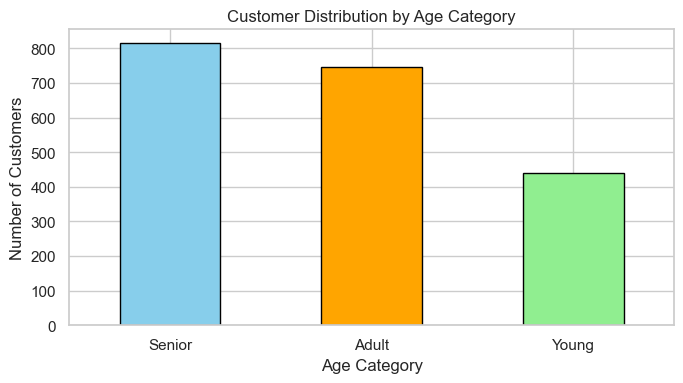

In [21]:
age_dist = customers['AgeCategory'].value_counts()
print(age_dist)

plt.figure(figsize=(7,4))
age_dist.plot(kind='bar', color=['skyblue','orange','lightgreen'], edgecolor='black')
plt.title('Customer Distribution by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Q3. Gender ke hisaab se total customers kitne hain?

Gender
Male      1045
Female     955
Name: count, dtype: int64


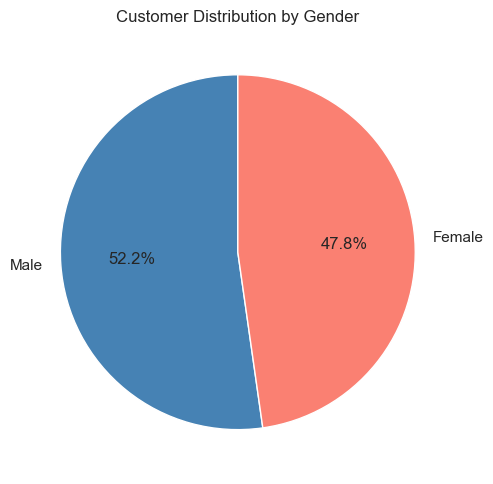

In [28]:
gender_dist = customers['Gender'].value_counts()
print(gender_dist)

gender_dist.plot(kind='pie', autopct='%1.1f%%', colors=['steelblue','salmon'], startangle=90)
plt.title('Customer Distribution by Gender')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Q4. Har Age Category ki average rating calculate karein.

AgeCategory
Adult     3.78
Senior    3.76
Young     3.74
Name: Rating, dtype: float64


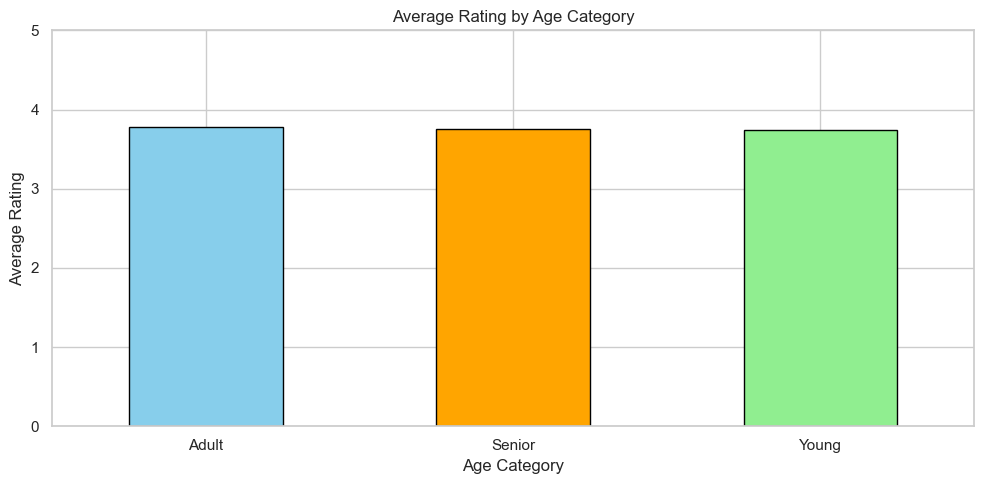

In [38]:
avg_rating_age = customers.groupby('AgeCategory')['Rating'].mean().round(2)
print(avg_rating_age)

avg_rating_age.plot(kind='bar', color=['skyblue','orange','lightgreen'], edgecolor='black')
plt.title('Average Rating by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

### Q5. Har gender ki average purchase value calculate karein.

Gender
Female    246.06
Male      252.06
Name: PurchaseValue, dtype: float64


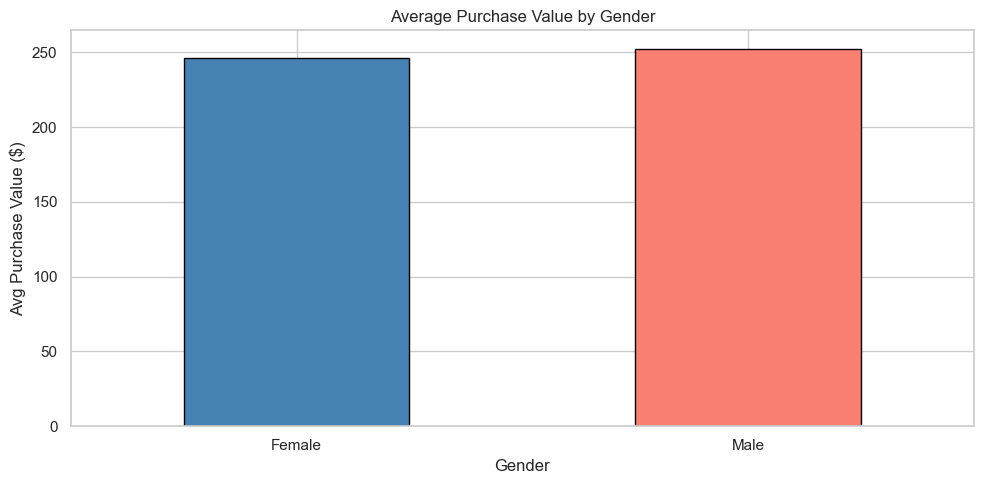

In [43]:
avg_purchase_gender = customers.groupby('Gender')['PurchaseValue'].mean().round(2)
print(avg_purchase_gender)

avg_purchase_gender.plot(kind='bar', color=['steelblue','salmon'], edgecolor='black')
plt.title('Average Purchase Value by Gender')
plt.xlabel('Gender')
plt.ylabel('Avg Purchase Value ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Q6. Kis country mein sabse zyada customers hain?

Country
USA          454
UK           372
Pakistan     246
India        242
Germany      230
France       211
Canada       154
Australia     91
Name: count, dtype: int64


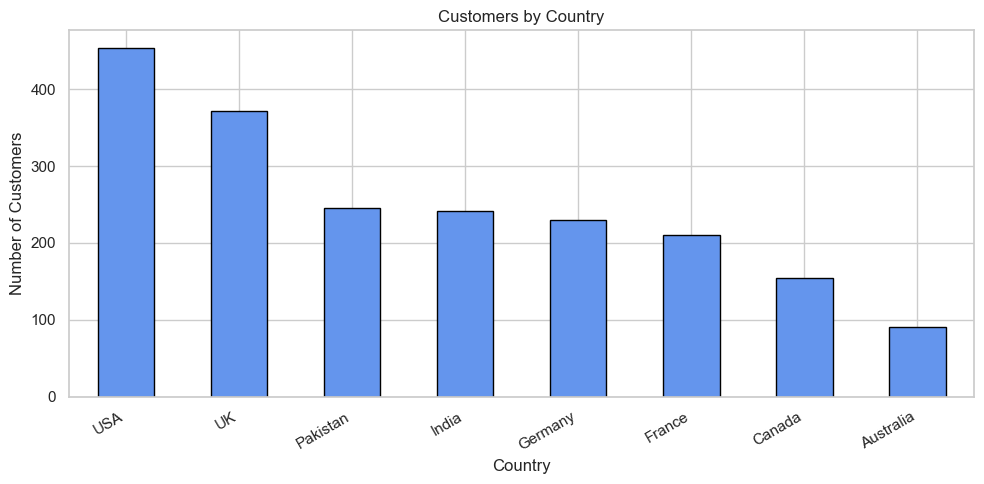

Sabse zyada customers: USA -> 454


In [47]:
country_dist = customers['Country'].value_counts()
print(country_dist)

country_dist.plot(kind='bar', color='cornflowerblue', edgecolor='black')
plt.title('Customers by Country')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

top_country = country_dist.idxmax()
print("Sabse zyada customers:", top_country, "->", country_dist.max())

### Q7. Har country ki average review rating calculate karein.

Country
Pakistan     3.83
Germany      3.77
India        3.76
Canada       3.76
USA          3.76
France       3.74
UK           3.74
Australia    3.69
Name: Rating, dtype: float64


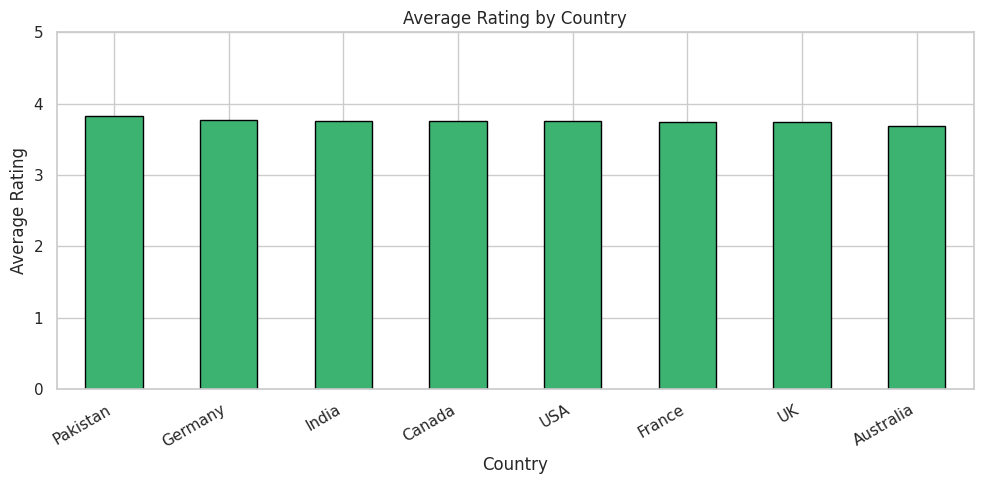

In [11]:
avg_rating_country = customers.groupby('Country')['Rating'].mean().round(2).sort_values(ascending=False)
print(avg_rating_country)

avg_rating_country.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Average Rating by Country')
plt.xlabel('Country')
plt.ylabel('Average Rating')
plt.ylim(0, 5)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Q8. Har country ka average engagement score nikaalein.

Country
Canada       66.79
Australia    65.59
India        65.44
UK           65.13
Pakistan     65.09
France       64.98
USA          64.52
Germany      64.43
Name: EngagementScore, dtype: float64


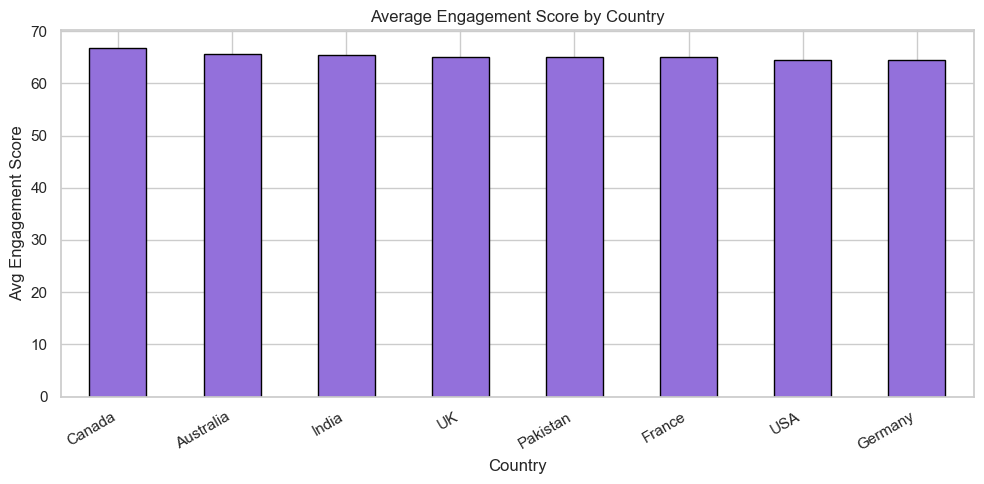

In [51]:
avg_eng_country = customers.groupby('Country')['EngagementScore'].mean().round(2).sort_values(ascending=False)
print(avg_eng_country)

avg_eng_country.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Average Engagement Score by Country')
plt.xlabel('Country')
plt.ylabel('Avg Engagement Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Q9. Kis age group ki engagement sabse zyada hai?

AgeCategory
Young     65.44
Adult     65.15
Senior    64.81
Name: EngagementScore, dtype: float64


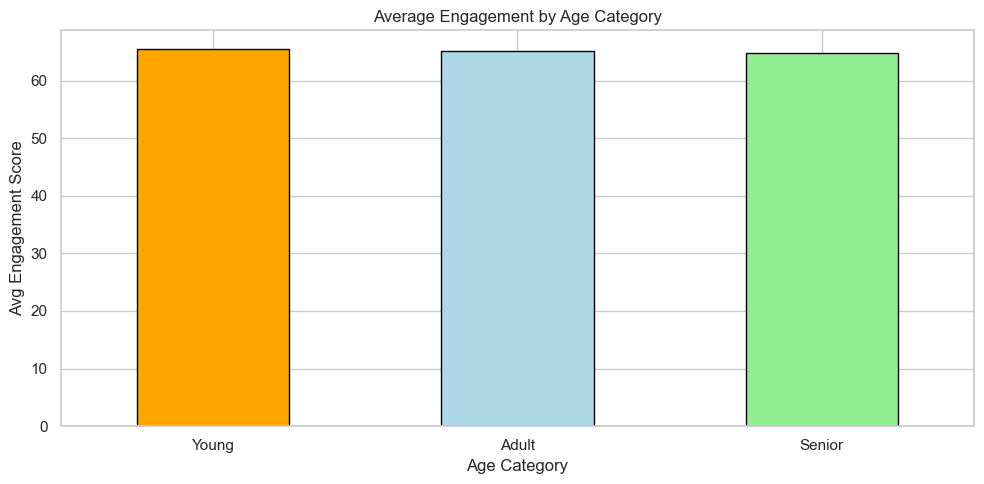

Sabse zyada engagement wala group: Young


In [56]:
avg_eng_age = customers.groupby('AgeCategory')['EngagementScore'].mean().round(2).sort_values(ascending=False)
print(avg_eng_age)

avg_eng_age.plot(kind='bar', color=['orange','lightblue','lightgreen'], edgecolor='black')
plt.title('Average Engagement by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Avg Engagement Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Sabse zyada engagement wala group:", avg_eng_age.idxmax())

### Q10. Kya male aur female customers ki average ratings mein koi difference hai?

Gender
Female    3.77
Male      3.76
Name: Rating, dtype: float64


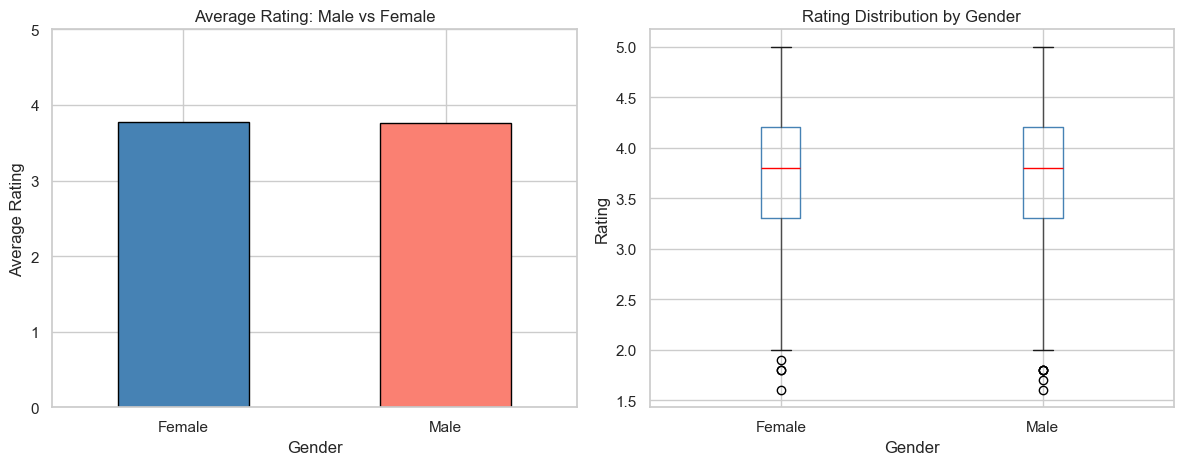

Rating difference: 0.01
Conclusion: Zyada difference nahi — dono genders ki ratings similar hain.


In [61]:
avg_rating_gender = customers.groupby('Gender')['Rating'].mean().round(2)
print(avg_rating_gender)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

avg_rating_gender.plot(kind='bar', ax=axes[0], color=['steelblue','salmon'], edgecolor='black')
axes[0].set_title('Average Rating: Male vs Female')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Average Rating')
axes[0].set_ylim(0, 5)
axes[0].tick_params(axis='x', rotation=0)

customers.boxplot(column='Rating', by='Gender', ax=axes[1],
                  boxprops=dict(color='steelblue'), medianprops=dict(color='red'))
axes[1].set_title('Rating Distribution by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Rating')
plt.suptitle('')
plt.tight_layout()
plt.show()

diff = abs(avg_rating_gender['Male'] - avg_rating_gender['Female'])
print(f"Rating difference: {diff:.2f}")
if diff < 0.3:
    print("Conclusion: Zyada difference nahi — dono genders ki ratings similar hain.")
else:
    print("Conclusion: Noticeable difference hai.")

---
## Product Analysis

### Q11. Sabse zyada purchase hone wale Top 10 products dikhayein.

       ProductName    Category  Purchases
Data Science Guide       Books       7652
          Sneakers      Sports       7007
       Cricket Bat      Sports       6773
            Tablet Electronics       5945
     Running Shoes      Sports       5896
      Fitness Band      Sports       5873
       Formal Suit    Clothing       5210
        Face Cream      Beauty       4846
          Yoga Mat      Sports       4656
  Wireless Earbuds Electronics       4024


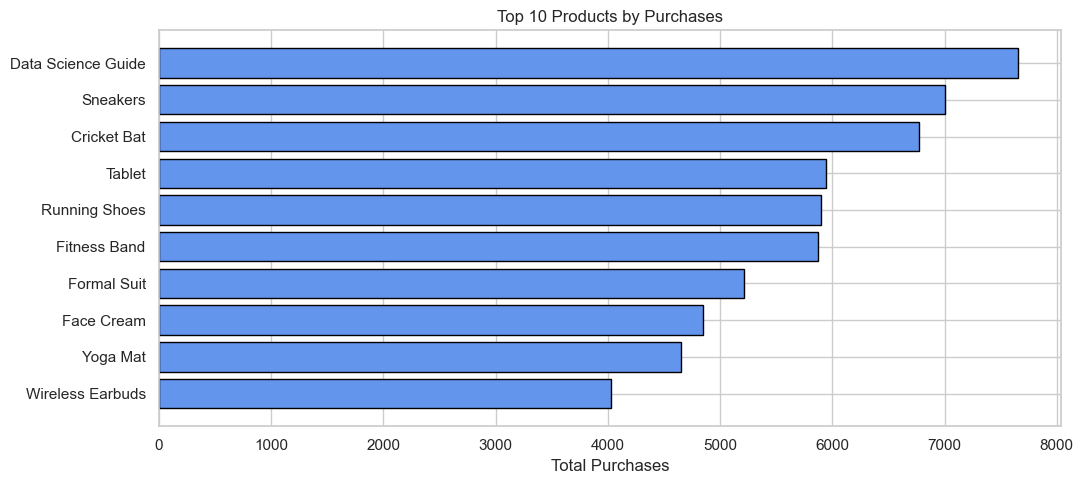

In [66]:
top10_purchases = products.nlargest(10, 'Purchases')[['ProductName','Category','Purchases']]
print(top10_purchases.to_string(index=False))

plt.figure(figsize=(11,5))
plt.barh(top10_purchases['ProductName'], top10_purchases['Purchases'], color='cornflowerblue', edgecolor='black')
plt.title('Top 10 Products by Purchases')
plt.xlabel('Total Purchases')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Q12. Sabse zyada reviews kis product ko mile hain?

In [82]:
top_reviews = products.nlargest(10, 'Reviews')[['ProductName','Category','Reviews']]
print(top_reviews.to_string(index=False))

top_reviewed_name = products.loc[products['Reviews'].idxmax(), 'ProductName']
top_reviewed_count = products['Reviews'].max()
print("Sabse zyada reviews:", top_reviewed_name, "->", top_reviewed_count, "reviews")

      ProductName      Category  Reviews
           RC Car          Toys     2998
    Winter Jacket      Clothing     2949
      Smart Watch   Electronics     2917
      Formal Suit      Clothing     2917
         Sofa Set Home & Garden     2832
      Cricket Bat        Sports     2557
       Hair Serum        Beauty     2275
Business Strategy         Books     2186
       Laptop Pro   Electronics     2159
   T-Shirt Bundle      Clothing     2144
Sabse zyada reviews: RC Car -> 2998 reviews


### Q13. Sabse zyada engagement wale Top 10 products identify karein.

       ProductName      Category  EngagementScore
        Garden Kit Home & Garden            61.80
          Yoga Mat        Sports            61.57
          Sneakers        Sports            60.70
       Cricket Bat        Sports            60.10
Data Science Guide         Books            59.51
       Formal Suit      Clothing            58.64
       Python Book         Books            55.80
      Fitness Band        Sports            55.49
           Perfume        Beauty            53.34
          LEGO Set          Toys            51.75


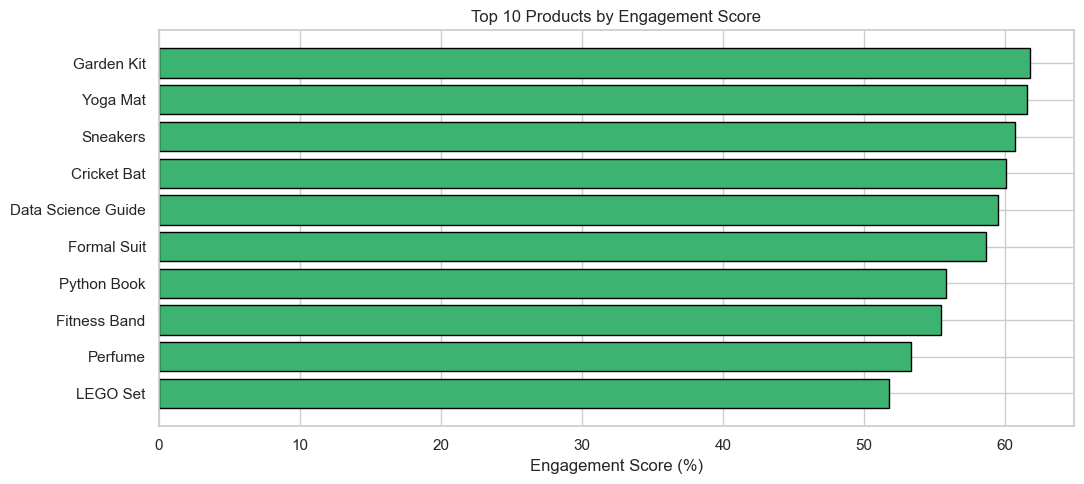

In [89]:
top10_eng = products.nlargest(10, 'EngagementScore')[['ProductName','Category','EngagementScore']]
print(top10_eng.to_string(index=False))

plt.figure(figsize=(11,5))
plt.barh(top10_eng['ProductName'], top10_eng['EngagementScore'], color='mediumseagreen', edgecolor='black')
plt.title('Top 10 Products by Engagement Score')
plt.xlabel('Engagement Score (%)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Q14. Har product category ki average rating calculate karein.

Category
Beauty           4.20
Clothing         4.10
Sports           4.10
Toys             4.10
Home & Garden    3.87
Books            3.77
Electronics      3.53
Food             3.47
Name: Rating, dtype: float64


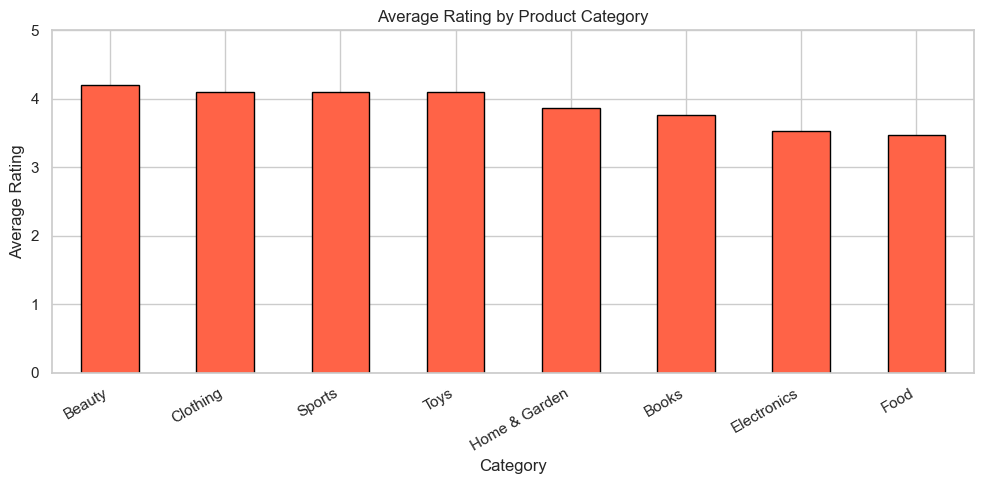

In [95]:
avg_rating_cat = products.groupby('Category')['Rating'].mean().round(2).sort_values(ascending=False)
print(avg_rating_cat)

avg_rating_cat.plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Average Rating by Product Category')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.ylim(0, 5)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Q15. Har category ki average engagement calculate karein.

Category
Sports           54.77
Books            52.07
Beauty           42.43
Home & Garden    41.54
Clothing         39.98
Toys             36.24
Electronics      35.36
Food             30.23
Name: EngagementScore, dtype: float64


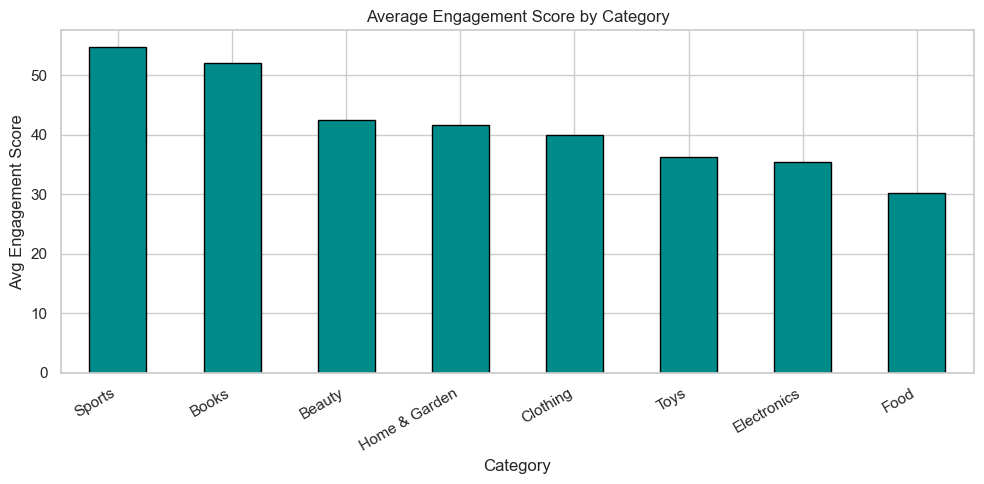

In [100]:
avg_eng_cat = products.groupby('Category')['EngagementScore'].mean().round(2).sort_values(ascending=False)
print(avg_eng_cat)

avg_eng_cat.plot(kind='bar', color='darkcyan', edgecolor='black')
plt.title('Average Engagement Score by Category')
plt.xlabel('Category')
plt.ylabel('Avg Engagement Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Q16. Har category ki average views aur clicks compare karein.

                 Views   Clicks
Category                       
Sports         67063.0  25234.0
Books          57982.0  20601.0
Beauty         53682.0  16114.0
Electronics    51067.0  13269.0
Food           44037.0  10417.0
Clothing       34388.0  10081.0
Home & Garden  20061.0   5008.0
Toys           19980.0   3827.0


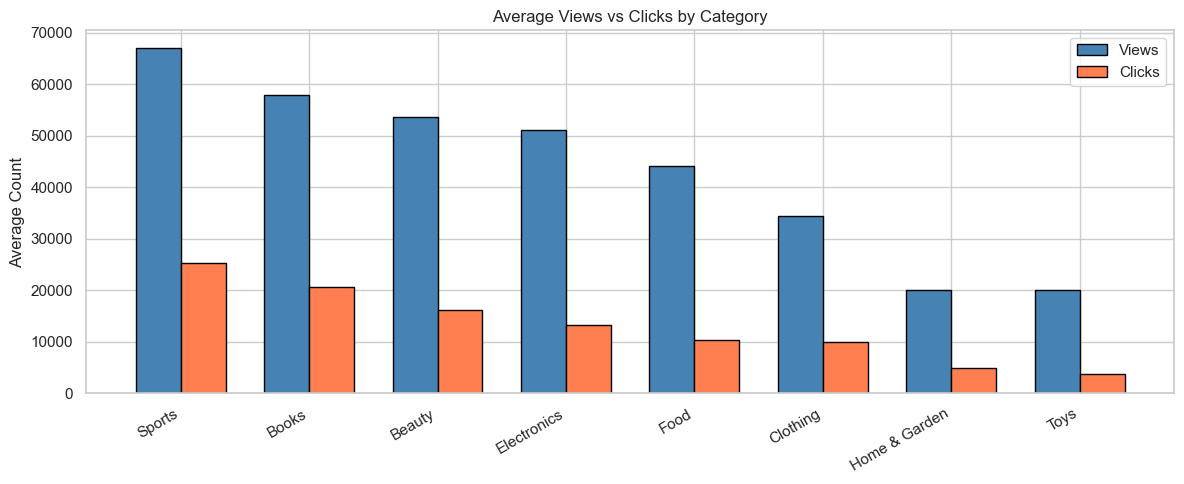

In [106]:
views_clicks = products.groupby('Category')[['Views','Clicks']].mean().round(0).sort_values('Views', ascending=False)
print(views_clicks)

x = range(len(views_clicks))
width = 0.35
plt.figure(figsize=(12,5))
plt.bar([i - width/2 for i in x], views_clicks['Views'],  width=width, label='Views',  color='steelblue', edgecolor='black')
plt.bar([i + width/2 for i in x], views_clicks['Clicks'], width=width, label='Clicks', color='coral',     edgecolor='black')
plt.xticks(list(x), views_clicks.index, rotation=30, ha='right')
plt.title('Average Views vs Clicks by Category')
plt.ylabel('Average Count')
plt.legend()
plt.tight_layout()
plt.show()

### Q17. Lowest rated Top 10 products kaun se hain?

       ProductName      Category  Rating
       Smart Watch   Electronics     3.0
     Winter Jacket      Clothing     3.0
          Sofa Set Home & Garden     3.1
         Green Tea          Food     3.1
  Wireless Earbuds   Electronics     3.2
        Laptop Pro   Electronics     3.4
    Protein Powder          Food     3.4
       Python Book         Books     3.5
Data Science Guide         Books     3.6
      Air Purifier Home & Garden     3.6


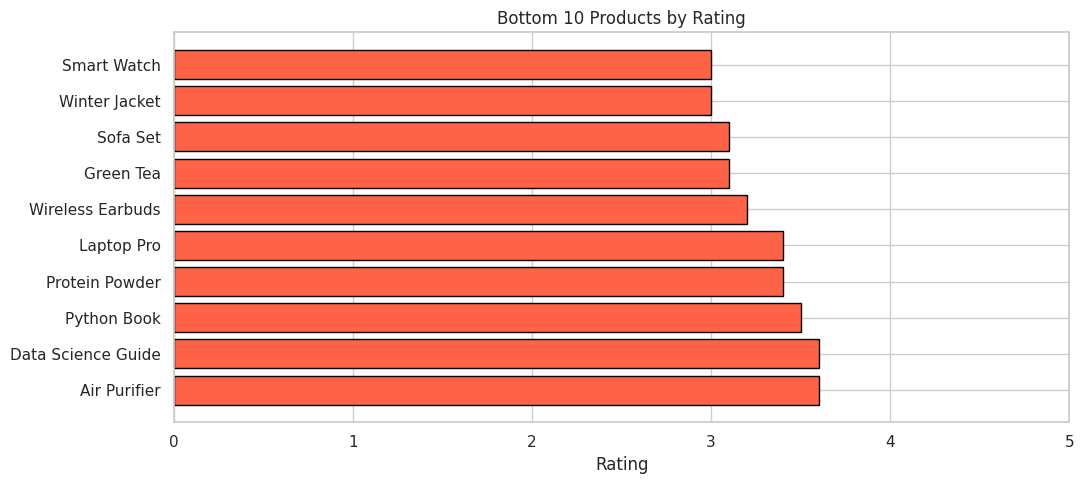

In [21]:
low_rated = products.nsmallest(10, 'Rating')[['ProductName','Category','Rating']]
print(low_rated.to_string(index=False))

plt.figure(figsize=(11,5))
plt.barh(low_rated['ProductName'], low_rated['Rating'], color='tomato', edgecolor='black')
plt.title('Bottom 10 Products by Rating')
plt.xlabel('Rating')
plt.xlim(0, 5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Q18. Highest rated Top 10 products kaun se hain?

      ProductName      Category  Rating
      Formal Suit      Clothing     4.9
       Garden Kit Home & Garden     4.9
         Yoga Mat        Sports     4.6
       Board Game          Toys     4.5
   T-Shirt Bundle      Clothing     4.4
       Hair Serum        Beauty     4.4
     Fitness Band        Sports     4.4
       Face Cream        Beauty     4.3
   Coffee Machine   Electronics     4.3
Business Strategy         Books     4.2


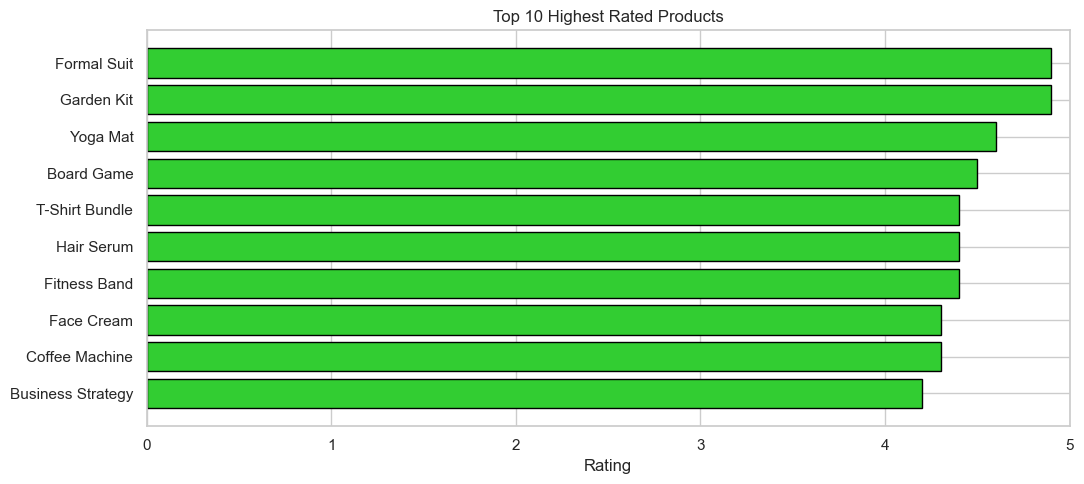

In [112]:
high_rated = products.nlargest(10, 'Rating')[['ProductName','Category','Rating']]
print(high_rated.to_string(index=False))

plt.figure(figsize=(11,5))
plt.barh(high_rated['ProductName'], high_rated['Rating'], color='limegreen', edgecolor='black')
plt.title('Top 10 Highest Rated Products')
plt.xlabel('Rating')
plt.xlim(0, 5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Q19. Kis category mein views zyada hain lekin purchases kam hain?

     Category  Total_Views  Total_Purchases  View_to_Purchase_Ratio
         Toys        59939             1971                    30.4
         Food       132112             5642                    23.4
  Electronics       306402            15762                    19.4
       Beauty       161046             9581                    16.8
Home & Garden        60184             3725                    16.2
     Clothing       103163             6602                    15.6
        Books       173947            12102                    14.4
       Sports       402376            33394                    12.0


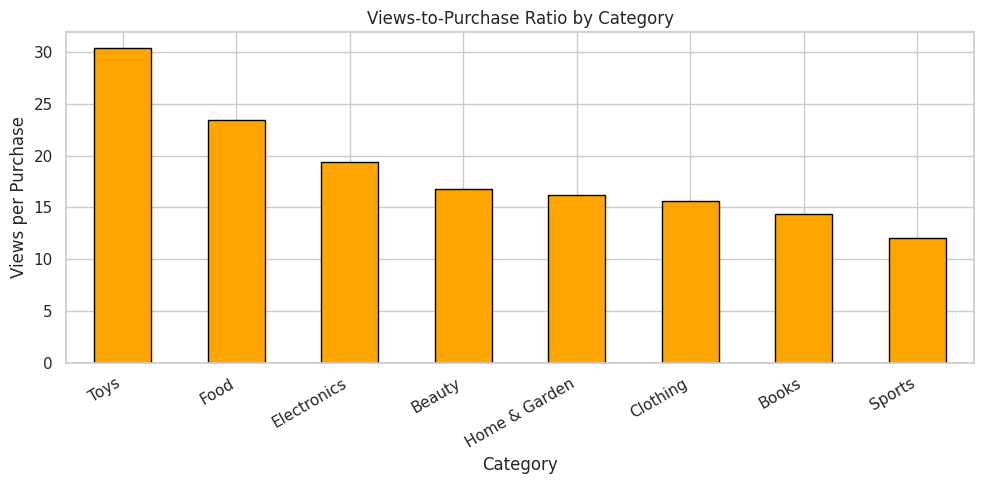

Sabse zyada views lekin kam purchases: Toys


In [23]:
cat_summary = products.groupby('Category').agg(
    Total_Views    = ('Views',     'sum'),
    Total_Purchases= ('Purchases', 'sum')
).reset_index()
cat_summary['View_to_Purchase_Ratio'] = (cat_summary['Total_Views'] / cat_summary['Total_Purchases']).round(1)
cat_summary_sorted = cat_summary.sort_values('View_to_Purchase_Ratio', ascending=False)
print(cat_summary_sorted.to_string(index=False))

cat_summary_sorted.plot(x='Category', y='View_to_Purchase_Ratio', kind='bar',
                        color='orange', edgecolor='black', legend=False)
plt.title('Views-to-Purchase Ratio by Category')
plt.xlabel('Category')
plt.ylabel('Views per Purchase')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("Sabse zyada views lekin kam purchases:", cat_summary_sorted.iloc[0]['Category'])

### Q20. Product popularity ko bar chart ke zariye visualize karein.

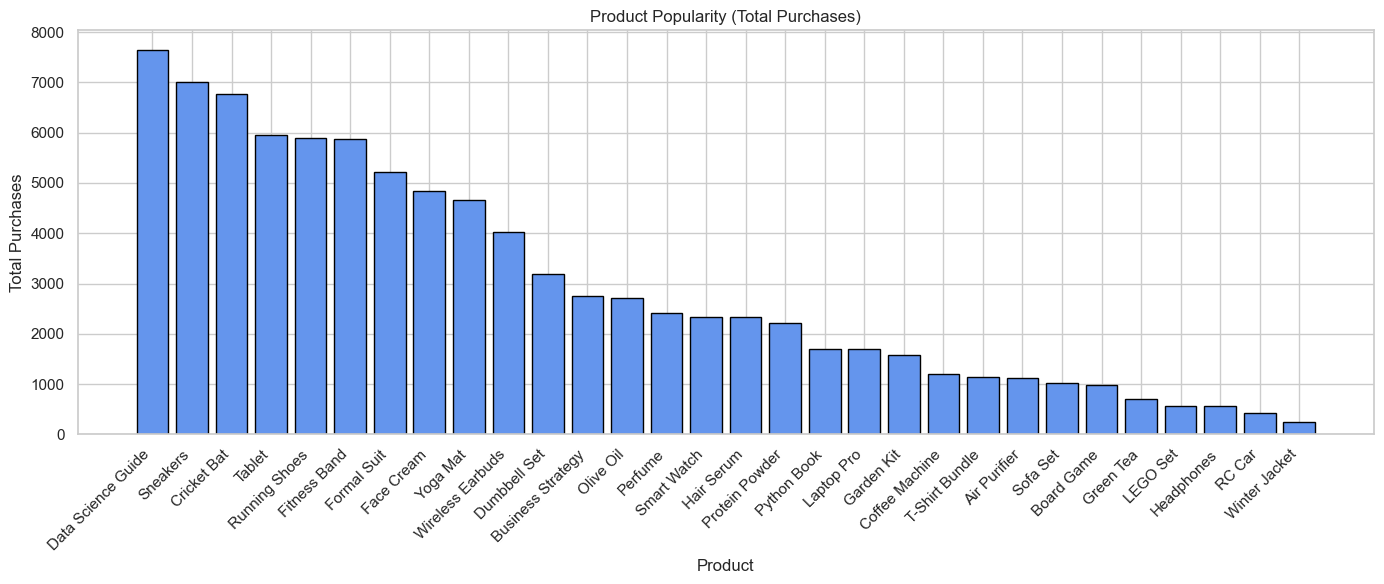

In [117]:
popularity = products[['ProductName','Purchases']].sort_values('Purchases', ascending=False)

plt.figure(figsize=(14,6))
plt.bar(popularity['ProductName'], popularity['Purchases'], color='cornflowerblue', edgecolor='black')
plt.title('Product Popularity (Total Purchases)')
plt.xlabel('Product')
plt.ylabel('Total Purchases')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## Engagement Analysis

### Q21. Total Views, Total Clicks aur Total Likes calculate karein.

Total Views  : 60,735
Total Clicks : 10,959
Total Likes  : 1,876


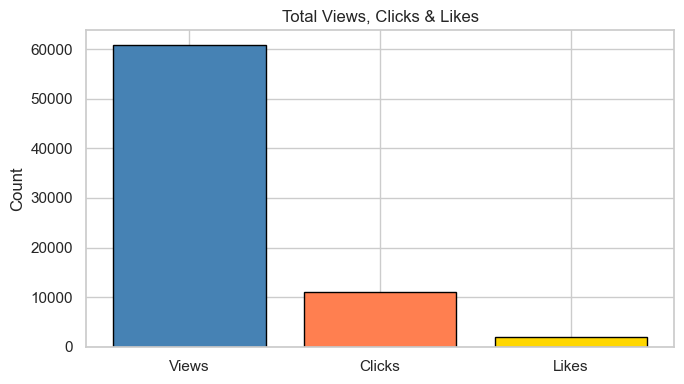

In [124]:
total_views  = engagement['Views'].sum()
total_clicks = engagement['Clicks'].sum()
total_likes  = engagement['Likes'].sum()

print(f"Total Views  : {total_views:,}")
print(f"Total Clicks : {total_clicks:,}")
print(f"Total Likes  : {total_likes:,}")

plt.figure(figsize=(7,4))
plt.bar(['Views','Clicks','Likes'], [total_views, total_clicks, total_likes],
        color=['steelblue','coral','gold'], edgecolor='black')
plt.title('Total Views, Clicks & Likes')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Q22. Overall Engagement Rate calculate karein.

In [132]:
overall_eng_rate = ((total_clicks + total_likes) / total_views * 100).round(2)
print(f"Overall Engagement Rate: {overall_eng_rate}%")

Overall Engagement Rate: 21.13%


### Q23. Har product ka Engagement Rate compare karein.

       ProductName  EngagementRate
Data Science Guide           27.81
    Protein Powder           24.11
     Running Shoes           23.51
      Dumbbell Set           23.45
     Winter Jacket           22.63
        Laptop Pro           22.46
        Garden Kit           22.39
       Cricket Bat           22.35
           Perfume           22.09
  Wireless Earbuds           22.07
        Headphones           21.87
       Python Book           21.23
            Tablet           21.16
      Air Purifier           21.08
          Sofa Set           20.99
          Sneakers           20.93
 Business Strategy           20.72
        Face Cream           20.65
      Fitness Band           20.56
    Coffee Machine           20.44
            RC Car           20.25
         Green Tea           20.22
        Hair Serum           19.83
         Olive Oil           19.67
    T-Shirt Bundle           19.53
          Yoga Mat           19.07
       Formal Suit           19.02
       Smart Watch  

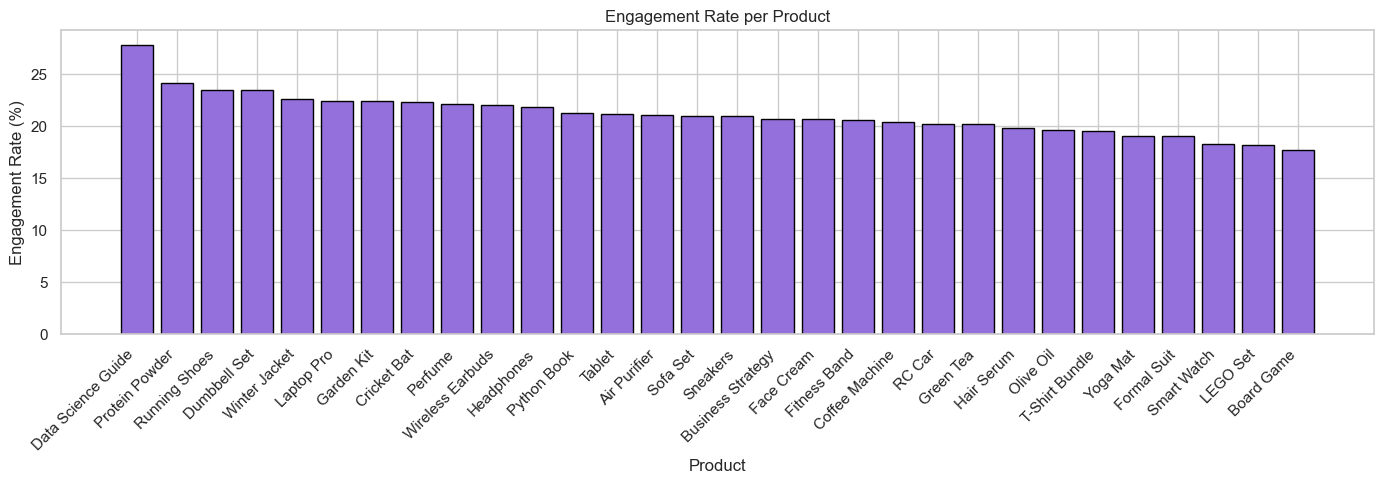

In [138]:
eng_by_product = engagement.groupby('ProductID').agg(
    Views  = ('Views',  'sum'),
    Clicks = ('Clicks', 'sum'),
    Likes  = ('Likes',  'sum')
).reset_index()
eng_by_product['EngagementRate'] = ((eng_by_product['Clicks'] + eng_by_product['Likes']) / eng_by_product['Views'] * 100).round(2)
eng_by_product = eng_by_product.merge(products[['ProductID','ProductName']], on='ProductID')
eng_sorted = eng_by_product.sort_values('EngagementRate', ascending=False)
print(eng_sorted[['ProductName','EngagementRate']].to_string(index=False))

plt.figure(figsize=(14,5))
plt.bar(eng_sorted['ProductName'], eng_sorted['EngagementRate'], color='mediumpurple', edgecolor='black')
plt.title('Engagement Rate per Product')
plt.xlabel('Product')
plt.ylabel('Engagement Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Q24. Sabse zyada viewed aur sabse zyada clicked products identify karein.

Top 5 Most Viewed Products:
   ProductName  Views
 Running Shoes   2314
    Face Cream   2247
 Winter Jacket   2156
T-Shirt Bundle   2130
    Garden Kit   2130
Top 5 Most Clicked Products:
       ProductName  Clicks
     Running Shoes     463
Data Science Guide     458
    Protein Powder     428
     Winter Jacket     419
        Garden Kit     406


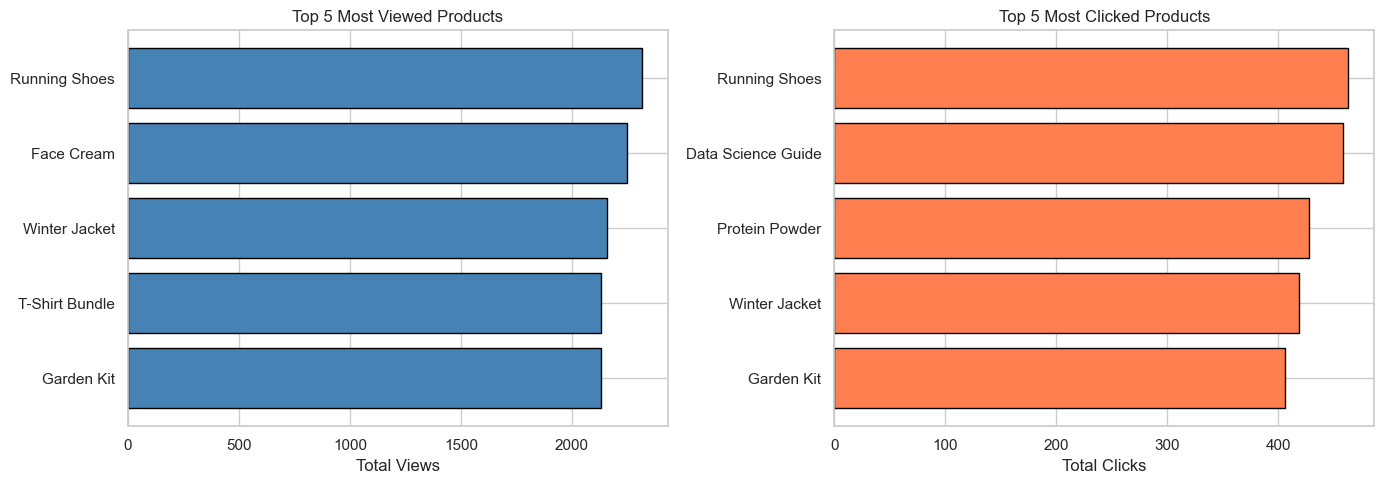

In [161]:
most_viewed  = eng_by_product.nlargest(5, 'Views')[['ProductName','Views']]
most_clicked = eng_by_product.nlargest(5, 'Clicks')[['ProductName','Clicks']]

print("Top 5 Most Viewed Products:")
print(most_viewed.to_string(index=False))
print("Top 5 Most Clicked Products:")
print(most_clicked.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].barh(most_viewed['ProductName'],  most_viewed['Views'],   color='steelblue', edgecolor='black')
axes[0].set_title('Top 5 Most Viewed Products')
axes[0].set_xlabel('Total Views')
axes[0].invert_yaxis()
axes[1].barh(most_clicked['ProductName'], most_clicked['Clicks'], color='coral',     edgecolor='black')
axes[1].set_title('Top 5 Most Clicked Products')
axes[1].set_xlabel('Total Clicks')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

### Q25. Least engaged products kaun se hain?

   ProductName  EngagementRate
    Board Game           17.67
      LEGO Set           18.22
   Smart Watch           18.27
   Formal Suit           19.02
      Yoga Mat           19.07
T-Shirt Bundle           19.53
     Olive Oil           19.67
    Hair Serum           19.83
     Green Tea           20.22
        RC Car           20.25


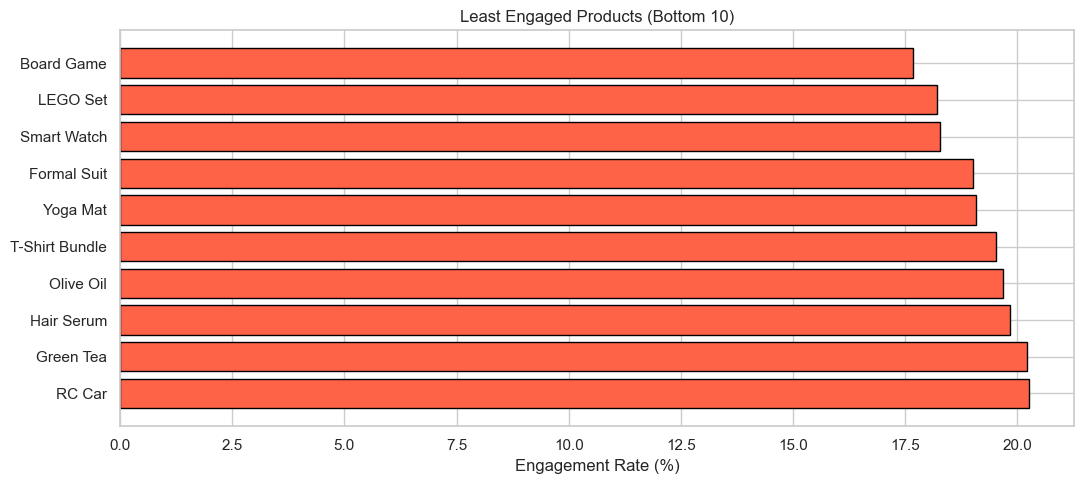

In [177]:
least_engaged = eng_sorted.nsmallest(10, 'EngagementRate')[['ProductName','EngagementRate']]
print(least_engaged.to_string(index=False))

plt.figure(figsize=(11,5))
plt.barh(least_engaged['ProductName'], least_engaged['EngagementRate'], color='tomato', edgecolor='black')
plt.title('Least Engaged Products (Bottom 10)')
plt.xlabel('Engagement Rate (%)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Q26. Monthly conversion trend visualize karein.

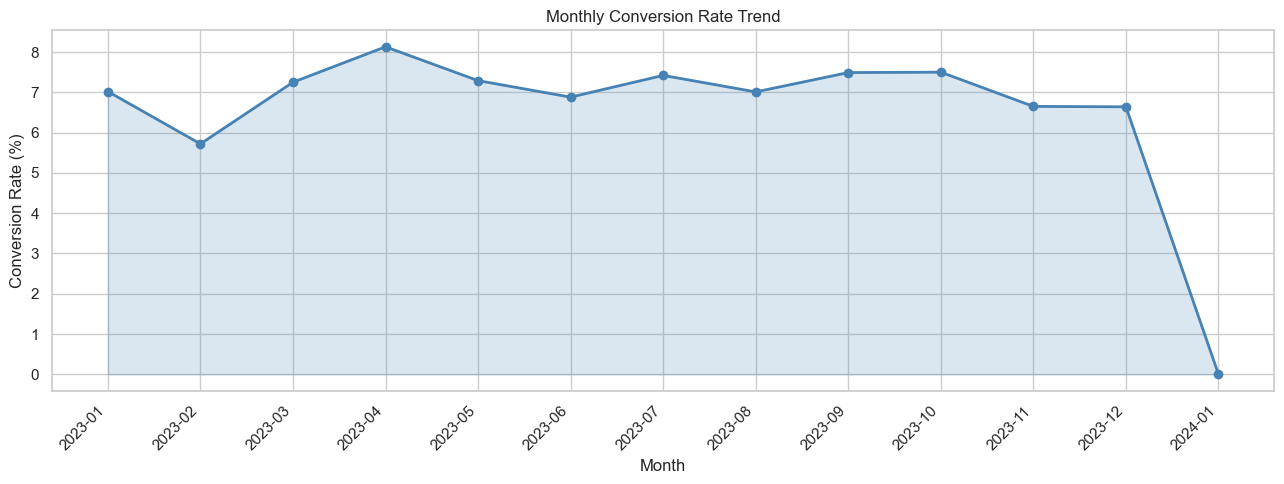

In [182]:
engagement['Date'] = pd.to_datetime(engagement['Date'])
engagement['Month'] = engagement['Date'].dt.to_period('M')

monthly = engagement.groupby('Month').agg(
    Total_Clicks    = ('Clicks',    'sum'),
    Total_Converted = ('Converted', 'sum')
).reset_index()
monthly['ConversionRate'] = (monthly['Total_Converted'] / monthly['Total_Clicks'].replace(0, np.nan) * 100).round(2)
monthly['Month_str'] = monthly['Month'].astype(str)

plt.figure(figsize=(13,5))
plt.plot(monthly['Month_str'], monthly['ConversionRate'], marker='o', color='steelblue', linewidth=2)
plt.fill_between(monthly['Month_str'], monthly['ConversionRate'], alpha=0.2, color='steelblue')
plt.title('Monthly Conversion Rate Trend')
plt.xlabel('Month')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Q27. Har campaign ka CTR (Click Through Rate) calculate karein.

CampaignID   CTR
  CAMP_006 20.90
  CAMP_016 19.64
  CAMP_014 19.64
  CAMP_001 19.50
  CAMP_018 19.24
  CAMP_003 18.85
  CAMP_009 18.70
  CAMP_004 18.60
  CAMP_011 18.20
  CAMP_010 18.18
  CAMP_019 17.77
  CAMP_008 17.61
  CAMP_005 17.58
  CAMP_013 17.42
  CAMP_020 17.38
  CAMP_002 17.07
  CAMP_012 16.61
  CAMP_015 16.42
  CAMP_007 16.39
  CAMP_017 15.66


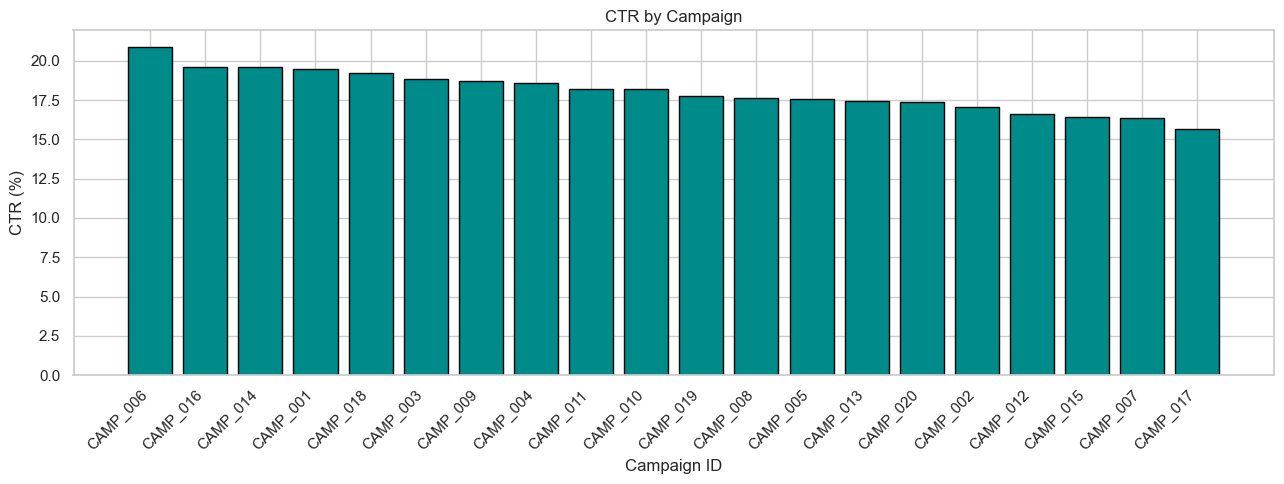

In [192]:
campaign_ctr = engagement.groupby('CampaignID').agg(
    Total_Views  = ('Views',  'sum'),
    Total_Clicks = ('Clicks', 'sum')
).reset_index()
campaign_ctr['CTR'] = (campaign_ctr['Total_Clicks'] / campaign_ctr['Total_Views'] * 100).round(2)
campaign_ctr_sorted = campaign_ctr.sort_values('CTR', ascending=False)
print(campaign_ctr_sorted[['CampaignID','CTR']].to_string(index=False))

plt.figure(figsize=(13,5))
plt.bar(campaign_ctr_sorted['CampaignID'], campaign_ctr_sorted['CTR'], color='darkcyan', edgecolor='black')
plt.title('CTR by Campaign')
plt.xlabel('Campaign ID')
plt.ylabel('CTR (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Q28. Top performing aur lowest performing campaigns identify karein.

Top 5 Performing Campaigns:
CampaignID   CTR
  CAMP_006 20.90
  CAMP_016 19.64
  CAMP_014 19.64
  CAMP_001 19.50
  CAMP_018 19.24
Bottom 5 Performing Campaigns:
CampaignID   CTR
  CAMP_002 17.07
  CAMP_012 16.61
  CAMP_015 16.42
  CAMP_007 16.39
  CAMP_017 15.66


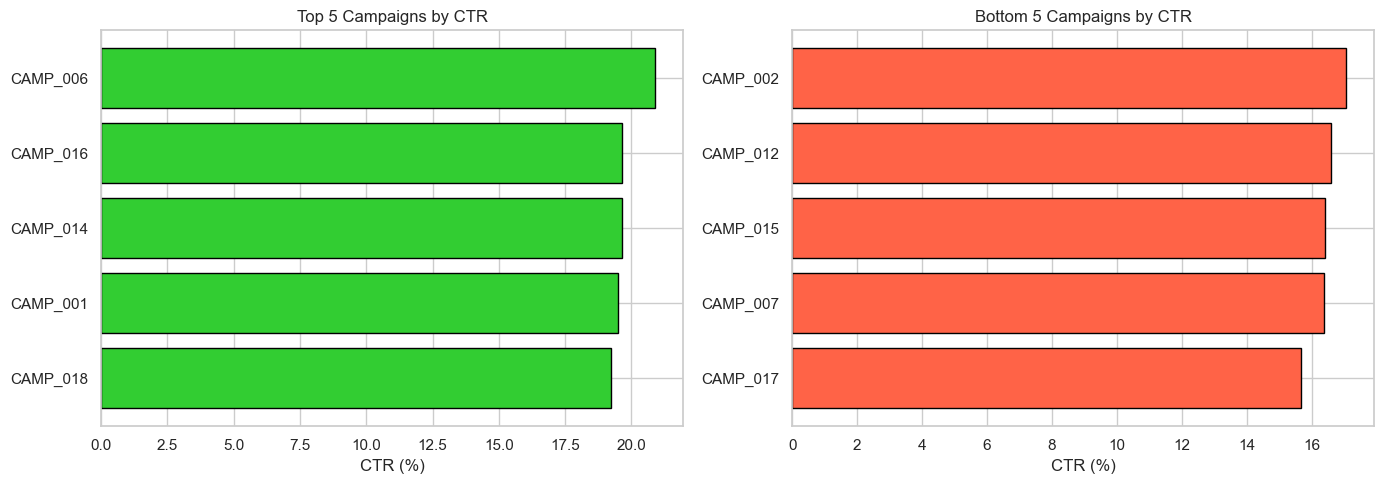

In [198]:
top_camps    = campaign_ctr_sorted.head(5)[['CampaignID','CTR']]
bottom_camps = campaign_ctr_sorted.tail(5)[['CampaignID','CTR']]

print("Top 5 Performing Campaigns:")
print(top_camps.to_string(index=False))
print("Bottom 5 Performing Campaigns:")
print(bottom_camps.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].barh(top_camps['CampaignID'],    top_camps['CTR'],    color='limegreen', edgecolor='black')
axes[0].set_title('Top 5 Campaigns by CTR')
axes[0].set_xlabel('CTR (%)')
axes[0].invert_yaxis()
axes[1].barh(bottom_camps['CampaignID'], bottom_camps['CTR'], color='tomato',    edgecolor='black')
axes[1].set_title('Bottom 5 Campaigns by CTR')
axes[1].set_xlabel('CTR (%)')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

---
## Combined Analysis

### Q29. Engagement aur ratings ke darmiyan relationship — Scatter Plot aur Correlation

Correlation between EngagementRate and Rating: -0.280


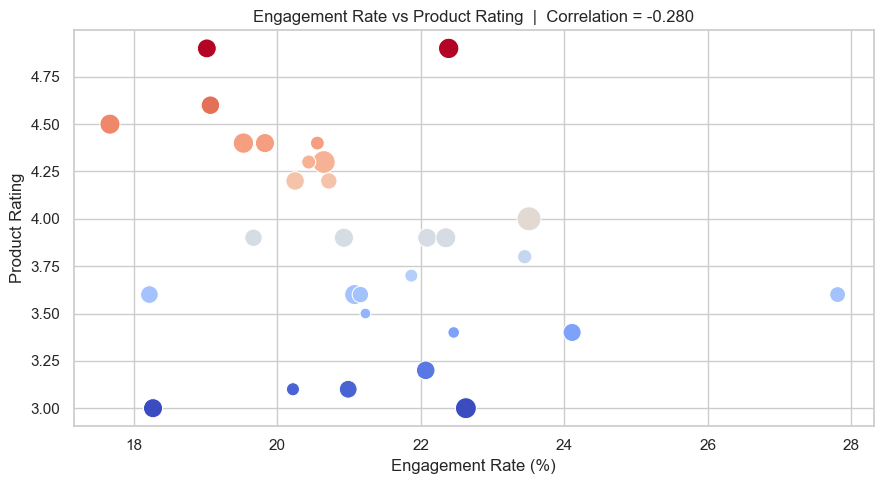

Insight: Weak correlation - high engagement does not guarantee high rating.


In [209]:
eng_agg = engagement.groupby('ProductID').agg(
    Total_Views    = ('Views',    'sum'),
    Total_Clicks   = ('Clicks',   'sum'),
    Total_Likes    = ('Likes',    'sum'),
    Total_Duration = ('Duration', 'sum')
).reset_index()
eng_agg['EngagementRate'] = ((eng_agg['Total_Clicks'] + eng_agg['Total_Likes']) / eng_agg['Total_Views'] * 100).round(2)

merged = eng_agg.merge(products[['ProductID','ProductName','Rating']], on='ProductID')
corr_val = merged['EngagementRate'].corr(merged['Rating'])
print(f"Correlation between EngagementRate and Rating: {corr_val:.3f}")

plt.figure(figsize=(9,5))
sns.scatterplot(data=merged, x='EngagementRate', y='Rating', hue='Rating',
                size='Total_Views', palette='coolwarm', sizes=(60,300), legend=False)
plt.title(f'Engagement Rate vs Product Rating  |  Correlation = {corr_val:.3f}')
plt.xlabel('Engagement Rate (%)')
plt.ylabel('Product Rating')
plt.tight_layout()
plt.show()

if abs(corr_val) < 0.3:
    print("Insight: Weak correlation - high engagement does not guarantee high rating.")
elif abs(corr_val) < 0.6:
    print("Insight: Moderate correlation - some relationship exists.")
else:
    print("Insight: Strong correlation - engagement and rating are closely linked.")

### Q30. Correlation Matrix (Heatmap) — Views, Clicks, Likes, Rating, Duration, Purchases

In [ ]:
final_merged = eng_agg.merge(products[['ProductID','Rating','Purchases']], on='ProductID')
final_merged = final_merged.rename(columns={
    'Total_Views'   : 'Views',
    'Total_Clicks'  : 'Clicks',
    'Total_Likes'   : 'Likes',
    'Total_Duration': 'Duration'
})

corr_cols = ['Views','Clicks','Likes','Rating','Duration','Purchases']
corr_matrix = final_merged[corr_cols].corr().round(2)
print(corr_matrix)

plt.figure(figsize=(9,7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Correlation Matrix: Views, Clicks, Likes, Rating, Duration, Purchases')
plt.tight_layout()
plt.show()

insights = [
    "Views aur Clicks mein strong positive correlation - zyada views = zyada clicks.",
    "Likes aur Clicks closely related - engaged users zyada like karte hain.",
    "Rating ka baaki metrics se weak correlation - quality aur popularity alag hoti hain.",
    "Purchases aur Views ka ratio conversion efficiency dikhata hai.",
    "Duration ka Views se relation: users kitna time spend kar rahe hain.",
]
print("Business Insights:")
for n, ins in enumerate(insights, 1):
    print(f"  {n}. {ins}")